In [ ]:
!pip install implicit
!pip install lightfm-next

In [ ]:
import json
import pandas as pd
import random
from tqdm import tqdm
from google.colab import drive
import matplotlib.pyplot as plt
from scipy.sparse import coo_matrix

SEED = 22
drive.mount('/content/drive')
import numpy as np
pd.options.display.max_rows = 50
pd.options.display.max_columns = 50

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
csv_file_path = '/content/drive/MyDrive/final_yelp_PA_FL.parquet'
df = pd.read_parquet(csv_file_path)
df

,review_id,user_id,business_id,stars,useful,funny,cool,text,date,name,address,city,state,postal_code,latitude,longitude,stars_business,review_count,is_open,attributes,categories,hours,name_user,review_count_user,yelping_since,useful_user,funny_user,cool_user,elite,friends,fans,average_stars,compliment_hot,compliment_more,compliment_profile,compliment_cute,compliment_list,compliment_note,compliment_plain,compliment_cool,compliment_funny,compliment_writer,compliment_photos,checkin_count,compliment_count
0,KU_O5udG6zpxOg-VcAEodg,mh_-eMZ6K5RLWhZyISBhwA,XQfwVwDr-v0ZS3_CbbE5Xw,3.0,0,0,0,"If you decide to eat here, just be aware it is...",2018-07-07 22:09:11,Turning Point of North Wales,1460 Bethlehem Pike,North Wales,PA,19454,40.210196,-75.223639,3.0,169,1,"{'AcceptsInsurance': None, 'AgesAllowed': None...","Restaurants, Breakfast & Brunch, Food, Juice B...","{'Friday': '7:30-15:0', 'Monday': '7:30-15:0',...",Melanie,33,2016-01-13 17:20:44,32,3,8,,"DS9QBM_NWJz1E279Zrao-A, XdXgIs4i5JFvtJf0rJlWsA...",0,4.06,0,0,0,0,0,0,0,1,1,0,0,177.0,0.0
1,BiTunyQ73aT9WBnpR9DZGw,OyoGAe7OKpv6SyGZT5g77Q,7ATYjTIgM3jUlt4UM3IypQ,5.0,1,0,1,I've taken a lot of spin classes over the year...,2012-01-03 15:28:18,Body Cycle Spinning Studio,"1923 Chestnut St, 2nd Fl",Philadelphia,PA,19119,39.952103,-75.172753,5.0,144,0,"{'AcceptsInsurance': None, 'AgesAllowed': None...","Active Life, Cycling Classes, Trainers, Gyms, ...","{'Friday': '6:0-19:30', 'Monday': '6:30-20:30'...",Erin,10,2011-03-07 19:45:15,6,1,2,,"7uYgWwryg8KH33i1SLJUTQ, 0mGJMNL8o2AY4BT1d4TTDQ...",0,4.30,0,0,0,0,0,0,0,0,0,0,0,497.0,0.0
2,J-4NdnDZ0pUQaUEEwDI9KQ,vrKkXsozqqecF3CW4cGaVQ,rjuWz_AD3WfXJc03AhIO_w,5.0,2,2,2,I thoroughly enjoyed the show. Chill way to s...,2012-12-04 16:46:20,The N Crowd,111 S Independence Mall E,Philadelphia,PA,19106,39.949756,-75.148062,4.5,90,1,"{'AcceptsInsurance': None, 'AgesAllowed': None...","Performing Arts, Arts & Entertainment, Nightli...","{'Friday': '19:15-21:15', 'Monday': '0:0-0:0',...",Mike,120,2010-08-16 19:59:54,48,17,31,,"ZaUT63HFjheiub1y7019Yg, Obkepp5aBTYVX-AL4zwBoQ...",5,4.44,4,3,0,0,0,10,15,4,4,4,0,148.0,0.0
3,DyrAIuKl60j_X8Yrrv-kpg,mNsVyC9tQVYtzLOCbh2Piw,MWmXGQ98KbRo3vsS5nZhMA,5.0,1,0,0,I recently had dinner here with my wife over t...,2014-10-27 02:47:28,Anthony's at Paxon Hollow,850 Paxon Hollow Rd,Broomall,PA,19008,39.958108,-75.371118,3.5,32,1,"{'AcceptsInsurance': None, 'AgesAllowed': None...","Event Planning & Services, Italian, Venues & E...","{'Friday': '12:0-21:0', 'Monday': None, 'Satur...",Michael,12,2014-07-20 22:56:07,43,6,2,,RKULSOrIvvYpDmtuYXEXzA,0,2.53,0,0,0,0,0,0,0,0,0,0,0,15.0,0.0
4,40thYphUgIfvJq17QCfTwA,QzCEzH3R7Z6erOGLr3t55Q,0pMj5xUAecW9o1P35B0AMw,5.0,1,0,1,Great staff always helps and always nice. Alwa...,2017-05-26 13:10:24,Wawa,2544 W Main Street,Norristown,PA,19403,40.141292,-75.389286,3.5,8,1,"{'AcceptsInsurance': None, 'AgesAllowed': None...","Food, Coffee & Tea, Gas Stations, Restaurants,...","{'Friday': '0:0-0:0', 'Monday': '0:0-0:0', 'Sa...",Kylhalil,14,2012-03-05 19:12:11,5,2,2,,"POmz_WtE-nowjX5H7s9NSA, PEYAcshPlYwY-YP-55Re4Q...",0,4.36,0,0,0,0,0,0,0,0,0,0,0,79.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
673685,rtt1Ymczj-1Lb26JMsY2lA,M1cMsRL4L7IUr9RILDywEQ,vt_esoDw6HG5ClM12OPkMg,4.0,4,3,4,"5 stars for the Bonte waffle, 3 stars for this...",2009-03-03 20:59:10,Bonté Wafflerie & Café,130 S 17th St,Philadelphia,PA,19102,39.950510,-75.169205,3.5,115,0,"{'AcceptsInsurance': None, 'AgesAllowed': None...","Coffee & Tea, Restaurants, Breakfast & Brunch,...","{'Friday': '6:30-18:0', 'Monday': '6:30-18:0',...",Matt,2227,2006-10-24 22:40:11,5681,1342,2430,"2008,2009,2010,2011,2012,2013,2014,2015,2016,2...","TLElemg3o3mlA4GGpupNiQ, REGjppkq2IkDLRQVmRj_Bg...",277,3.78,59,30,10,13,36,79,116,150,150,128,41,193.0,0.0
673686,5n_oSwXspiiSsZgNwjp48g,bJ5FtCtZX3ZZacz2_2PJjA,SOsjW1JARmtHUFtpFlp8rw,4.0,5,

In [ ]:
df['text'][1]

"I've taken a lot of spin classes over the years, and nothing compares to the classes at Body Cycle. From the nice, clean space and amazing bikes, to the welcoming and motivating instructors, every class is a top notch work out.\n\nFor anyone who struggles to fit workouts in, the online scheduling system makes it easy to plan ahead (and there's no need to line up way in advanced like many gyms make you do).\n\nThere is no way I can write this review without giving Russell, the owner of Body Cycle, a shout out. Russell's passion for fitness and cycling is so evident, as is his desire for all of his clients to succeed. He is always dropping in to classes to check in/provide encouragement, and is open to ideas and recommendations from anyone. Russell always wears a smile on his face, even when he's kicking your butt in class!"

rows: 673690 users: 87154 items: 48208
date range: 2005-03-18 01:49:32 -> 2022-01-19 19:29:46
duplicate rows (user-item): 15489
user-item pairs with repeats: 14284

per-user interactions:  mean/median/p90/max = 7.729880441517314 4.0 14.0 1135
per-item interactions:  mean/median/p90/max = 13.9746515101228 5.0 32.0 1467


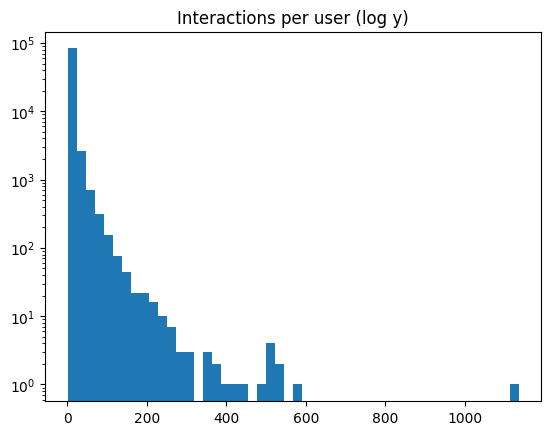

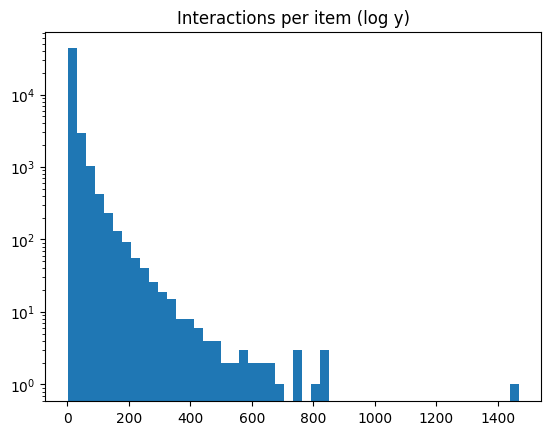

after filters/users: 40666 items: 19983
train_inner: 383457 val_inner: 40666 train_outer: 424123 test_outer: 32057
dropped test cold-start (pos item not in item universe): 8654
share users with eval_first < train_last (should be 0): 0.0
share eval events where pos NOT in train history (should be 1): 0.9690404760733783
share users with eval_first < train_last (should be 0): 0.0
share eval events where pos NOT in train history (should be 1): 0.9621923448856724
candidate set size per user: mean/median/p10/p90/min = 19972.830398858998 19977.0 19963.0 19980.0 19254


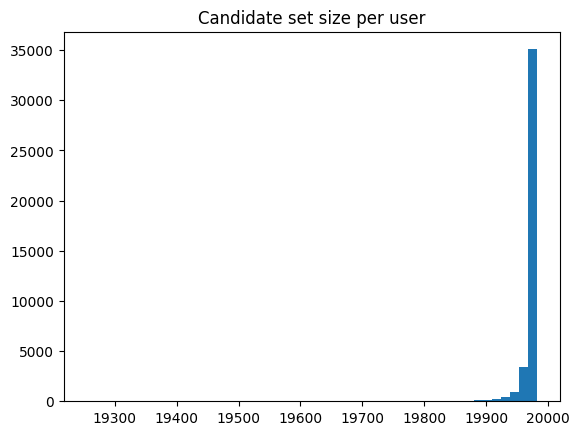

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def diag_basic(df, user_col="user_id", item_col="business_id", date_col="date"):
    d = df.copy()
    d[date_col] = pd.to_datetime(d[date_col], errors="coerce")
    d = d.dropna(subset=[user_col, item_col, date_col])
    print("rows:", len(d), "users:", d[user_col].nunique(), "items:", d[item_col].nunique())
    print("date range:", d[date_col].min(), "->", d[date_col].max())

    # duplicates user-item
    dup_rows = d.duplicated([user_col, item_col]).sum()
    dup_pairs = (d.groupby([user_col, item_col]).size() > 1).sum()
    print("duplicate rows (user-item):", int(dup_rows))
    print("user-item pairs with repeats:", int(dup_pairs))

    # per-user / per-item counts
    u_cnt = d.groupby(user_col)[item_col].size()
    i_cnt = d.groupby(item_col)[user_col].size()
    print("\nper-user interactions:  mean/median/p90/max =",
          float(u_cnt.mean()), float(u_cnt.median()), float(u_cnt.quantile(0.9)), int(u_cnt.max()))
    print("per-item interactions:  mean/median/p90/max =",
          float(i_cnt.mean()), float(i_cnt.median()), float(i_cnt.quantile(0.9)), int(i_cnt.max()))

    # plots (no fixed colors)
    fig = plt.figure()
    plt.hist(u_cnt.values, bins=50)
    plt.yscale("log")
    plt.title("Interactions per user (log y)")
    plt.show()

    fig = plt.figure()
    plt.hist(i_cnt.values, bins=50)
    plt.yscale("log")
    plt.title("Interactions per item (log y)")
    plt.show()

def lmroo_split(df, user_col="user_id", item_col="business_id", date_col="date",
                min_user_inter=5, min_item_inter=5, k_test=1, k_val=1):
    d = df.copy()
    d[date_col] = pd.to_datetime(d[date_col], errors="coerce")
    d = d.dropna(subset=[user_col, item_col, date_col]).sort_values([user_col, date_col]).reset_index(drop=True)

    # user filter
    u_cnt = d.groupby(user_col)[item_col].size()
    users_ok = u_cnt[u_cnt >= min_user_inter].index
    d = d[d[user_col].isin(users_ok)].copy()

    # outer test (last k per user)
    test_idx = d.groupby(user_col).tail(k_test).index
    test_outer = d.loc[test_idx].copy()
    train_outer = d.drop(test_idx).copy()

    # item universe from outer-train (no leakage)
    i_cnt = train_outer.groupby(item_col)[user_col].size()
    items_ok = i_cnt[i_cnt >= min_item_inter].index
    train_outer = train_outer[train_outer[item_col].isin(items_ok)].copy()
    test_outer_before = len(test_outer)
    test_outer = test_outer[test_outer[item_col].isin(items_ok)].copy()
    dropped_test_cold = test_outer_before - len(test_outer)

    # inner val (last k inside outer-train)
    val_idx = train_outer.groupby(user_col).tail(k_val).index
    val_inner = train_outer.loc[val_idx].copy()
    train_inner = train_outer.drop(val_idx).copy()

    print("after filters/users:", train_outer[user_col].nunique(), "items:", train_outer[item_col].nunique())
    print("train_inner:", len(train_inner), "val_inner:", len(val_inner),
          "train_outer:", len(train_outer), "test_outer:", len(test_outer))
    print("dropped test cold-start (pos item not in item universe):", int(dropped_test_cold))

    return train_inner, val_inner, train_outer, test_outer

def diag_split_quality(train_df, eval_df, user_col="user_id", item_col="business_id", date_col="date"):
    tr = train_df.sort_values([user_col, date_col])
    ev = eval_df.sort_values([user_col, date_col])

    # time ordering check: eval date should be >= last train date per user
    tr_last = tr.groupby(user_col)[date_col].max()
    ev_first = ev.groupby(user_col)[date_col].min()
    joined = pd.concat([tr_last, ev_first], axis=1, keys=["train_last", "eval_first"]).dropna()
    bad = (joined["eval_first"] < joined["train_last"]).mean()
    print("share users with eval_first < train_last (should be 0):", float(bad))

    # pos item must not be in train history for that user (next-item setting)
    tr_hist = tr.groupby(user_col)[item_col].apply(set)
    ok = 0
    total = 0
    for u, g in ev.groupby(user_col):
        hist = tr_hist.get(u, set())
        for it in g[item_col].tolist():
            total += 1
            ok += int(it not in hist)
    print("share eval events where pos NOT in train history (should be 1):", ok / max(total, 1))

def diag_candidates(train_df, user_col="user_id", item_col="business_id"):
    n_items = train_df[item_col].nunique()
    hist_sizes = train_df.groupby(user_col)[item_col].nunique()
    cand = n_items - hist_sizes
    print("candidate set size per user: mean/median/p10/p90/min =",
          float(cand.mean()), float(cand.median()), float(cand.quantile(0.1)),
          float(cand.quantile(0.9)), int(cand.min()))
    fig = plt.figure()
    plt.hist(cand.values, bins=50)
    plt.title("Candidate set size per user")
    plt.show()

# ====== USAGE ======
# df must contain: user_id, business_id, date
diag_basic(df)

train_inner, val_inner, train_outer, test_outer = lmroo_split(
    df, min_user_inter=5, min_item_inter=5, k_test=1, k_val=1
)
diag_split_quality(train_inner, val_inner)
diag_split_quality(train_outer, test_outer)
diag_candidates(train_outer)


In [ ]:
import numpy as np, pandas as pd

item_cnt = df.groupby("business_id").size().sort_values(ascending=False)
n_items = item_cnt.size
n_inter = item_cnt.sum()

def top_share(p):  # p in [0,1]
    k = max(1, int(p*n_items))
    return item_cnt.iloc[:k].sum() / n_inter

print("items:", n_items, "interactions:", n_inter)
print("median/p90/p99/max:", item_cnt.median(), item_cnt.quantile(0.9), item_cnt.quantile(0.99), item_cnt.max())
for p in [0.001, 0.01, 0.05, 0.10]:
    print(f"Top {p*100:.1f}% items share:", round(top_share(p), 4))

print("items with >=100 interactions:", int((item_cnt>=100).sum()))
print("items with >=500 interactions:", int((item_cnt>=500).sum()))


items: 48208 interactions: 673690
median/p90/p99/max: 5.0 32.0 140.0 1467
Top 0.1% items share: 0.0391
Top 1.0% items share: 0.1696
Top 5.0% items share: 0.4035
Top 10.0% items share: 0.551
items with >=100 interactions: 907
items with >=500 interactions: 22


In [ ]:
def gini(x):
    x = np.asarray(x, dtype=np.float64)
    x = x[x>=0]
    if x.sum() == 0: return 0.0
    x = np.sort(x)
    n = x.size
    cum = np.cumsum(x)
    return (n + 1 - 2*np.sum(cum)/cum[-1]) / n

print("Gini(item popularity):", round(gini(item_cnt.values), 4))


Gini(item popularity): 0.6616


In [ ]:
import numpy as np
import pandas as pd
from scipy.sparse import coo_matrix

SEED = 42
np.random.seed(SEED)

MIN_USER_INTERACTIONS = 5
MIN_ITEM_INTERACTIONS = 5

K_TEST = 1  # outer LMROO-1
K_VAL  = 1  # inner LMROO-1 (внутри train0)
KS = (5, 10, 20, 50)

assert MIN_USER_INTERACTIONS >= (K_TEST + K_VAL + 1), "иначе train_inner может стать пустым"

df0 = df.copy()
df0["date"] = pd.to_datetime(df0["date"], errors="coerce")
df0 = df0.dropna(subset=["user_id", "business_id", "date"]).sort_values(["user_id", "date"])

# user-filter по полному df0 (как у вас)
user_cnt = df0.groupby("user_id")["business_id"].size()
eligible_users = user_cnt[user_cnt >= MIN_USER_INTERACTIONS].index
df_cf = df0[df0["user_id"].isin(eligible_users)].copy()

print("Users after filter:", df_cf["user_id"].nunique())
print("Total interactions:", len(df_cf))


Users after filter: 40711
Total interactions: 519891


In [ ]:
test_idx = df_cf.groupby("user_id").tail(K_TEST).index
test0  = df_cf.loc[test_idx, ["user_id","business_id","date"]].copy()
train0 = df_cf.drop(test_idx).loc[:, ["user_id","business_id","date"]].copy()

print("train0:", len(train0), "test0:", len(test0))


train0: 479180 test0: 40711


In [ ]:
val_idx = train0.groupby("user_id").tail(K_VAL).index
val0 = train0.loc[val_idx, ["user_id","business_id","date"]].copy()
train_inner0 = train0.drop(val_idx).loc[:, ["user_id","business_id","date"]].copy()

print("train_inner0:", len(train_inner0), "val0:", len(val0), "test0:", len(test0))

min_hist = train_inner0.groupby("user_id")["business_id"].size().min()
print("min interactions per user in train_inner0:", int(min_hist))


train_inner0: 438469 val0: 40711 test0: 40711
min interactions per user in train_inner0: 3


## Индексация по train, CSR матрица, cold-start чистка теста

In [ ]:
def build_split_objects(train_df, eval_df, min_item_interactions=5):
    """
    train_df, eval_df: DataFrame с колонками user_id, business_id (date можно, но не нужно)
    Делает:
      1) item-filter по train_df
      2) индексация пользователей/items по train_df после фильтра
      3) drop cold-start в eval_df
      4) строит R (CSR) по train_df_f (бинарная)
      5) user_train_items, all_items, eval_u/eval_i
    """
    # item-filter (без утечки)
    item_cnt = train_df.groupby("business_id")["user_id"].size()
    eligible_items = item_cnt[item_cnt >= min_item_interactions].index

    train_f = train_df[train_df["business_id"].isin(eligible_items)].copy()
    eval_f  = eval_df[eval_df["business_id"].isin(eligible_items)].copy()

    # индексация по train_f
    users = train_f["user_id"].unique()
    items = train_f["business_id"].unique()
    user2idx = {u:i for i,u in enumerate(users)}
    item2idx = {b:i for i,b in enumerate(items)}

    train_f["u"] = train_f["user_id"].map(user2idx).astype("int32")
    train_f["i"] = train_f["business_id"].map(item2idx).astype("int32")

    eval_f["u"] = eval_f["user_id"].map(user2idx)
    eval_f["i"] = eval_f["business_id"].map(item2idx)

    before = len(eval_f)
    eval_f = eval_f.dropna(subset=["u","i"]).copy()
    eval_f["u"] = eval_f["u"].astype("int32")
    eval_f["i"] = eval_f["i"].astype("int32")
    dropped = before - len(eval_f)

    n_users = len(users)
    n_items = len(items)

    R = coo_matrix(
        (np.ones(len(train_f), dtype=np.float32),
         (train_f["u"].values, train_f["i"].values)),
        shape=(n_users, n_items)
    ).tocsr()

    user_train_items = train_f.groupby("u")["i"].apply(lambda x: set(x.tolist())).to_dict()
    all_items = np.arange(n_items, dtype=np.int32)

    eval_u = eval_f["u"].values
    eval_i = eval_f["i"].values

    # sanity
    if len(eval_f) > 0:
        assert eval_f["u"].max() < R.shape[0]
        assert eval_f["i"].max() < R.shape[1]

    info = {
        "n_users": n_users,
        "n_items": n_items,
        "R": R,
        "train_f": train_f,
        "eval_f": eval_f,
        "eval_u": eval_u,
        "eval_i": eval_i,
        "user_train_items": user_train_items,
        "all_items": all_items,
        "dropped_cold_start": dropped
    }
    return info


## Единые метрики и evaluator (быстрее, без iterrows)

In [ ]:
def _ndcg_from_rank(rank: int) -> float:
    return 1.0 / np.log2(rank + 2)

def _ap_from_rank(rank: int) -> float:
    return 1.0 / (rank + 1)

def evaluate_next_item(eval_u, eval_i, recommend_fn, ks=KS, name="model"):
    ks = tuple(sorted(ks))
    maxK = ks[-1]

    rec = {k: 0.0 for k in ks}
    ndcg = {k: 0.0 for k in ks}
    mp = {k: 0.0 for k in ks}

    short_lists = 0
    n = len(eval_u)

    for u, pos in zip(eval_u, eval_i):
        recs = recommend_fn(int(u), int(maxK))
        if recs is None:
            recs = np.array([], dtype=np.int32)
        else:
            recs = np.asarray(recs, dtype=np.int32)

        if len(recs) < maxK:
            short_lists += 1

        rank_map = {int(it): r for r, it in enumerate(recs)}
        rpos = rank_map.get(int(pos), None)

        for k in ks:
            if rpos is None or rpos >= k:
                continue
            rec[k] += 1.0
            ndcg[k] += _ndcg_from_rank(rpos)
            mp[k] += _ap_from_rank(rpos)

    out = {k: (rec[k]/n, ndcg[k]/n, mp[k]/n) for k in ks}
    print(f"[{name}] short rec lists: {short_lists}/{n} ({short_lists/n:.3f})")
    return out

def print_metrics(name, out, ks=KS):
    print(f"\n=== {name} ===")
    for k in ks:
        r, n, m = out[k]
        print(f"K={k:2d} | Recall@{k}: {r:.4f} | NDCG@{k}: {n:.4f} | MAP@{k}: {m:.4f}")


In [ ]:
val_pack  = build_split_objects(train_inner0, val0,  min_item_interactions=MIN_ITEM_INTERACTIONS)
test_pack = build_split_objects(train0,       test0, min_item_interactions=MIN_ITEM_INTERACTIONS)

print("VAL: n_users/n_items:", val_pack["n_users"], val_pack["n_items"],
      "| eval:", len(val_pack["eval_u"]), "| dropped cold:", val_pack["dropped_cold_start"])

print("TEST: n_users/n_items:", test_pack["n_users"], test_pack["n_items"],
      "| eval:", len(test_pack["eval_u"]), "| dropped cold:", test_pack["dropped_cold_start"])


VAL: n_users/n_items: 40593 18699 | eval: 32656 | dropped cold: 55
TEST: n_users/n_items: 40666 19983 | eval: 32032 | dropped cold: 25


## Baselines: Popular + Random

In [ ]:
def run_popularity(pack, name_prefix=""):
    train_f = pack["train_f"]
    eval_u, eval_i = pack["eval_u"], pack["eval_i"]
    user_train_items = pack["user_train_items"]

    item_pop = train_f.groupby("i")["u"].nunique().sort_values(ascending=False)
    pop_ranked_items = item_pop.index.values.astype(np.int32)

    def recommend_pop(u, K):
        seen = user_train_items.get(u, set())
        recs = []
        for it in pop_ranked_items:
            if int(it) not in seen:
                recs.append(int(it))
                if len(recs) == K:
                    break
        return np.asarray(recs, dtype=np.int32)

    out = evaluate_next_item(eval_u, eval_i, recommend_pop, ks=KS, name=f"{name_prefix}Popularity")
    print_metrics(f"{name_prefix}Popularity", out, ks=KS)
    return out

out_pop_val  = run_popularity(val_pack,  name_prefix="VAL/")
out_pop_test = run_popularity(test_pack, name_prefix="TEST/")


[VAL/Popularity] short rec lists: 0/32656 (0.000)

=== VAL/Popularity ===
K= 5 | Recall@5: 0.0070 | NDCG@5: 0.0045 | MAP@5: 0.0036
K=10 | Recall@10: 0.0130 | NDCG@10: 0.0064 | MAP@10: 0.0044
K=20 | Recall@20: 0.0221 | NDCG@20: 0.0087 | MAP@20: 0.0051
K=50 | Recall@50: 0.0415 | NDCG@50: 0.0125 | MAP@50: 0.0057
[TEST/Popularity] short rec lists: 0/32032 (0.000)

=== TEST/Popularity ===
K= 5 | Recall@5: 0.0076 | NDCG@5: 0.0049 | MAP@5: 0.0040
K=10 | Recall@10: 0.0131 | NDCG@10: 0.0066 | MAP@10: 0.0047
K=20 | Recall@20: 0.0212 | NDCG@20: 0.0086 | MAP@20: 0.0052
K=50 | Recall@50: 0.0391 | NDCG@50: 0.0122 | MAP@50: 0.0058


In [ ]:
def run_random(pack, name_prefix="", seed=SEED):
    rng = np.random.default_rng(seed)
    eval_u, eval_i = pack["eval_u"], pack["eval_i"]
    user_train_items = pack["user_train_items"]
    all_items = pack["all_items"]
    n_items = pack["n_items"]

    def recommend_random(u, K):
        seen = user_train_items.get(u, set())
        if len(seen) >= n_items:
            return np.array([], dtype=np.int32)

        candidates = np.setdiff1d(all_items, np.fromiter(seen, dtype=np.int32), assume_unique=False)
        if candidates.size <= K:
            return candidates.astype(np.int32)

        return rng.choice(candidates, size=K, replace=False).astype(np.int32)

    out = evaluate_next_item(eval_u, eval_i, recommend_random, ks=KS, name=f"{name_prefix}Random")
    print_metrics(f"{name_prefix}Random", out, ks=KS)
    return out

out_rand_val  = run_random(val_pack,  name_prefix="VAL/")
out_rand_test = run_random(test_pack, name_prefix="TEST/")


[VAL/Random] short rec lists: 0/32656 (0.000)

=== VAL/Random ===
K= 5 | Recall@5: 0.0001 | NDCG@5: 0.0001 | MAP@5: 0.0000
K=10 | Recall@10: 0.0004 | NDCG@10: 0.0002 | MAP@10: 0.0001
K=20 | Recall@20: 0.0010 | NDCG@20: 0.0003 | MAP@20: 0.0001
K=50 | Recall@50: 0.0029 | NDCG@50: 0.0007 | MAP@50: 0.0002
[TEST/Random] short rec lists: 0/32032 (0.000)

=== TEST/Random ===
K= 5 | Recall@5: 0.0003 | NDCG@5: 0.0002 | MAP@5: 0.0001
K=10 | Recall@10: 0.0004 | NDCG@10: 0.0002 | MAP@10: 0.0001
K=20 | Recall@20: 0.0008 | NDCG@20: 0.0003 | MAP@20: 0.0002
K=50 | Recall@50: 0.0021 | NDCG@50: 0.0006 | MAP@50: 0.0002


## ItemKNN (implicit) + опциональные веса (raw/tfidf/bm25)

In [ ]:
import numpy as np
import pandas as pd
from implicit.nearest_neighbours import CosineRecommender, tfidf_weight, bm25_weight

def eval_itemknn_on_pack(pack, weighting="bm25", K_sim=100, bm25_K1=1.2, bm25_B=0.75, target_k=50):
    R = pack["R"].tocsr()
    eval_u, eval_i = pack["eval_u"], pack["eval_i"]

    # weighting
    if weighting == "raw":
        Rw = R
    elif weighting == "tfidf":
        Rw = tfidf_weight(R).tocsr()
    elif weighting == "bm25":
        Rw = bm25_weight(R, K1=bm25_K1, B=bm25_B).tocsr()
    else:
        raise ValueError("weighting must be one of: raw/tfidf/bm25")

    # fit
    model = CosineRecommender(K=K_sim)
    model.fit(Rw.T.tocsr())  # item-user

    # recommend
    def rec(u, K):
        items, _ = model.recommend(
            userid=int(u),
            user_items=Rw[u],
            N=int(K),
            filter_already_liked_items=True
        )
        return np.asarray(items, dtype=np.int32)

    out = evaluate_next_item(eval_u, eval_i, rec, ks=KS, name=f"ItemKNN({weighting},K={K_sim})")
    score = out[target_k][0]  # Recall@target_k
    return score, out


In [ ]:

TARGET_K = 50


weightings = ["raw", "tfidf", "bm25"]
K_sims = [10,15, 20, 50, 100, 200]
bm25_grid = [(1.2, 0.75), (1.2, 0.5), (0.9, 0.75)]

rows = []
best = (-1.0, None, None)  # (best_score, best_params, best_out)

for w in weightings:
    if w == "bm25":
        for K_sim in K_sims:
            for (K1, B) in bm25_grid:
                score, out = eval_itemknn_on_pack(val_pack, weighting=w, K_sim=K_sim, bm25_K1=K1, bm25_B=B, target_k=TARGET_K)
                rows.append({"weighting": w, "K_sim": K_sim, "K1": K1, "B": B,
                             **{f"Recall@{k}": out[k][0] for k in KS},
                             **{f"NDCG@{k}": out[k][1] for k in KS},
                             **{f"MAP@{k}": out[k][2] for k in KS}})
                if score > best[0]:
                    best = (score, (w, K_sim, K1, B), out)
    else:
        for K_sim in K_sims:
            score, out = eval_itemknn_on_pack(val_pack, weighting=w, K_sim=K_sim, target_k=TARGET_K)
            rows.append({"weighting": w, "K_sim": K_sim, "K1": None, "B": None,
                         **{f"Recall@{k}": out[k][0] for k in KS},
                         **{f"NDCG@{k}": out[k][1] for k in KS},
                         **{f"MAP@{k}": out[k][2] for k in KS}})
            if score > best[0]:
                best = (score, (w, K_sim, None, None), out)

df_knn_val = pd.DataFrame(rows).sort_values(f"Recall@{TARGET_K}", ascending=False)

print("BEST on VAL:", best[1], f"Recall@{TARGET_K}={best[0]:.6f}")
print_metrics(f"VAL/ItemKNN best {best[1]}", best[2], ks=KS)

df_knn_val.head(10)


/usr/local/lib/python3.12/dist-packages/implicit/utils.py:164: ParameterWarning: Method expects CSR input, and was passed coo_matrix instead. Converting to CSR took 0.0034637451171875 seconds
  warnings.warn(


  0%|          | 0/40593 [00:00<?, ?it/s]

[ItemKNN(raw,K=10)] short rec lists: 15621/32656 (0.478)


/usr/local/lib/python3.12/dist-packages/implicit/utils.py:164: ParameterWarning: Method expects CSR input, and was passed coo_matrix instead. Converting to CSR took 0.004258394241333008 seconds
  warnings.warn(


  0%|          | 0/40593 [00:00<?, ?it/s]

...

[ItemKNN(bm25,K=200)] short rec lists: 73/32656 (0.002)


/usr/local/lib/python3.12/dist-packages/implicit/utils.py:164: ParameterWarning: Method expects CSR input, and was passed coo_matrix instead. Converting to CSR took 0.002962350845336914 seconds
  warnings.warn(


  0%|          | 0/40593 [00:00<?, ?it/s]

[ItemKNN(bm25,K=200)] short rec lists: 73/32656 (0.002)
BEST on VAL: ('tfidf', 10, None, None) Recall@50=0.016995

=== VAL/ItemKNN best ('tfidf', 10, None, None) ===
K= 5 | Recall@5: 0.0002 | NDCG@5: 0.0001 | MAP@5: 0.0001
K=10 | Recall@10: 0.0007 | NDCG@10: 0.0003 | MAP@10: 0.0001
K=20 | Recall@20: 0.0035 | NDCG@20: 0.0009 | MAP@20: 0.0003
K=50 | Recall@50: 0.0170 | NDCG@50: 0.0035 | MAP@50: 0.0007


,weighting,K_sim,K1,B,Recall@5,Recall@10,Recall@20,Recall@50,NDCG@5,NDCG@10,NDCG@20,NDCG@50,MAP@5,MAP@10,MAP@20,MAP@50
6,tfidf,10,NaN,NaN,0.000153,0.000735,0.003460,0.016995,0.000090,0.000260,0.000889,0.003509,0.000070,0.000129,0.000272,0.000664
13,bm25,10,1.2,0.50,0.000153,0.000735,0.003491,0.016965,0.000094,0.000262,0.000899,0.003506,0.000074,0.000132,0.000277,0.000666
12,bm25,10,1.2,0.75,0.000153,0.000704,0.003491,0.016965,0.000094,0.000253,0.000898,0.003505,0.000074,0.000129,0.000276,0.000665
14,bm25,10,0.9,0.75,0.000153,0.000674,0.003430,0.016965,0.000094,0.000244,0.000883,0.003502,0.000074,0.000126,0.000272,0.000663
0,raw,10,NaN,NaN,0.000061,0.000735,0.003338,0.016720,0.000042,0.000241,0.000840,0.003434,0.000037,0.000108,0.000243,0.000632
7,tfidf,15,NaN,NaN,0.000184,0.000276,0.001011,0.010197,0.000106,0.000134,0.000317,0.002052,0.000080,0.000091,0.000139,0.000382
17,bm25,15,0.9,0.75,0.000184,0.000214,0.001011,0.010197,0.000109,0.000118,0.000317,0.002053,0.000084,0.000087,0.000141,0.000384
16,bm25,15,1.2,0.50,0.000184,0.000276,0.001011,0.010197,0.000109,0.000136,0.000319,0.002055,0.000084,0.000093,0.000142,0.000385
15,bm25,15,1.2,0.75,0.000184,0.000245,0.001011,0.010197,0.000109,0.000127,0.000318,0.002054,0.000084,0.000090,0.000141,0.000384
1,raw,15,NaN,NaN,0.000092,0.000276,0.000888,0.009952,0.000073,0.000130,0.000284,0.001997,0.000067,0.000089,0.000131,0.000371


In [ ]:
best_score, best_params, _ = best
w, K_sim, K1, B = best_params

if w == "bm25":
    _, out_knn_test = eval_itemknn_on_pack(test_pack, weighting=w, K_sim=K_sim, bm25_K1=K1, bm25_B=B, target_k=TARGET_K)
else:
    _, out_knn_test = eval_itemknn_on_pack(test_pack, weighting=w, K_sim=K_sim, target_k=TARGET_K)

print_metrics(f"TEST/ItemKNN best {best_params}", out_knn_test, ks=KS)


/usr/local/lib/python3.12/dist-packages/implicit/utils.py:164: ParameterWarning: Method expects CSR input, and was passed coo_matrix instead. Converting to CSR took 0.0037314891815185547 seconds
  warnings.warn(


  0%|          | 0/40666 [00:00<?, ?it/s]

[ItemKNN(tfidf,K=10)] short rec lists: 10999/32032 (0.343)

=== TEST/ItemKNN best ('tfidf', 10, None, None) ===
K= 5 | Recall@5: 0.0001 | NDCG@5: 0.0001 | MAP@5: 0.0001
K=10 | Recall@10: 0.0006 | NDCG@10: 0.0002 | MAP@10: 0.0001
K=20 | Recall@20: 0.0020 | NDCG@20: 0.0006 | MAP@20: 0.0002
K=50 | Recall@50: 0.0171 | NDCG@50: 0.0034 | MAP@50: 0.0006


## BPR (implicit) как “bpe/bpr” baseline

In [ ]:
import numpy as np
from implicit.bpr import BayesianPersonalizedRanking

def eval_bpr_on_pack(pack, factors=64, learning_rate=0.05, regularization=0.002, iterations=200, target_k=50):
    R = pack["R"].tocsr()  # user-item
    eval_u, eval_i = pack["eval_u"], pack["eval_i"]

    bpr = BayesianPersonalizedRanking(
        factors=int(factors),
        learning_rate=float(learning_rate),
        regularization=float(regularization),
        iterations=int(iterations),
        random_state=SEED
    )
    bpr.fit(R)

    # sanity (как у вас)
    assert bpr.user_factors.shape[0] == R.shape[0]
    assert bpr.item_factors.shape[0] == R.shape[1]

    def recommend_bpr(u, K):
        user_row = R[int(u)]
        items, _ = bpr.recommend(
            userid=int(u),
            user_items=user_row,
            N=int(K),
            filter_already_liked_items=True
        )
        return np.asarray(items, dtype=np.int32)

    out = evaluate_next_item(eval_u, eval_i, recommend_bpr, ks=KS, name=f"BPR(f={factors},it={iterations})")
    score = out[target_k][0]  # Recall@target_k
    return score, out


In [ ]:
import pandas as pd
from itertools import product

TARGET_K = 50  # можно 10

grid_bpr = {
    "factors":  [64, 128],
    "learning_rate": [0.01, 0.05],
    "regularization": [0.001, 0.002],
    "iterations": [100, 200],
}

rows = []
best = (-1.0, None, None)

for f, lr, reg, it in product(grid_bpr["factors"], grid_bpr["learning_rate"], grid_bpr["regularization"], grid_bpr["iterations"]):
    score, out = eval_bpr_on_pack(val_pack, factors=f, learning_rate=lr, regularization=reg, iterations=it, target_k=TARGET_K)
    rows.append({
        "factors": f, "learning_rate": lr, "regularization": reg, "iterations": it,
        **{f"Recall@{k}": out[k][0] for k in KS},
        **{f"NDCG@{k}": out[k][1] for k in KS},
        **{f"MAP@{k}": out[k][2] for k in KS},
    })
    if score > best[0]:
        best = (score, (f, lr, reg, it), out)

df_bpr_val = pd.DataFrame(rows).sort_values(f"Recall@{TARGET_K}", ascending=False)
print("BEST BPR on VAL:", best[1], f"Recall@{TARGET_K}={best[0]:.6f}")
print_metrics(f"VAL/BPR best {best[1]}", best[2], ks=KS)

df_bpr_val.head(10)


  0%|          | 0/100 [00:00<?, ?it/s]

[BPR(f=64,it=100)] short rec lists: 0/32656 (0.000)


  0%|          | 0/200 [00:00<?, ?it/s]

[BPR(f=64,it=200)] short rec lists: 0/32656 (0.000)


  0%|          | 0/100 [00:00<?, ?it/s]

...

  0%|          | 0/100 [00:00<?, ?it/s]

[BPR(f=128,it=100)] short rec lists: 0/32656 (0.000)


  0%|          | 0/200 [00:00<?, ?it/s]

[BPR(f=128,it=200)] short rec lists: 0/32656 (0.000)
BEST BPR on VAL: (128, 0.01, 0.002, 200) Recall@50=0.067645

=== VAL/BPR best (128, 0.01, 0.002, 200) ===
K= 5 | Recall@5: 0.0104 | NDCG@5: 0.0065 | MAP@5: 0.0052
K=10 | Recall@10: 0.0190 | NDCG@10: 0.0092 | MAP@10: 0.0063
K=20 | Recall@20: 0.0341 | NDCG@20: 0.0130 | MAP@20: 0.0073
K=50 | Recall@50: 0.0676 | NDCG@50: 0.0195 | MAP@50: 0.0083


,factors,learning_rate,regularization,iterations,Recall@5,Recall@10,Recall@20,Recall@50,NDCG@5,NDCG@10,NDCG@20,NDCG@50,MAP@5,MAP@10,MAP@20,MAP@50
11,128,0.01,0.002,200,0.010442,0.018955,0.034052,0.067645,0.006485,0.009200,0.012972,0.019539,0.005202,0.006300,0.007311,0.008326
9,128,0.01,0.001,200,0.010320,0.019078,0.033715,0.066756,0.006452,0.009247,0.012912,0.019400,0.005195,0.006326,0.007313,0.008327
1,64,0.01,0.001,200,0.011238,0.019200,0.032919,0.066695,0.006884,0.009402,0.012849,0.019495,0.005472,0.006478,0.007413,0.008457
3,64,0.01,0.002,200,0.010902,0.019323,0.033348,0.066634,0.006604,0.009298,0.012807,0.019352,0.005208,0.006303,0.007247,0.008273
7,64,0.05,0.002,200,0.009156,0.016812,0.029214,0.061398,0.005514,0.007982,0.011077,0.017400,0.004327,0.005341,0.006170,0.007159
6,64,0.05,0.002,100,0.009677,0.017393,0.029704,0.060418,0.005972,0.008460,0.011538,0.017579,0.004763,0.005786,0.006612,0.007560
15,128,0.05,0.002,200,0.008329,0.015985,0.027897,0.060387,0.005054,0.007494,0.010477,0.016853,0.003991,0.004978,0.005781,0.006776
4,64,0.05,0.001,100,0.010167,0.017393,0.029367,0.059193,0.006243,0.008557,0.011557,0.017427,0.004963,0.005905,0.006715,0.007637
5,64,0.05,0.001,200,0.009217,0.016199,0.028081,0.058948,0.005600,0.007828,0.010818,0.016886,0.004427,0.005329,0.006143,0.007093
12,128,0.05,0.001,100,0.009279,0.016720,0.027438,0.057019,0.005699,0.008081,0.010779,0.016630,0.004533,0.005502,0.006235,0.007167


In [ ]:
f, lr, reg, it = best[1]
_, out_bpr_test = eval_bpr_on_pack(test_pack, factors=f, learning_rate=lr, regularization=reg, iterations=it, target_k=TARGET_K)
print_metrics(f"TEST/BPR best (f={f},lr={lr},reg={reg},it={it})", out_bpr_test, ks=KS)


  0%|          | 0/200 [00:00<?, ?it/s]

[BPR(f=128,it=200)] short rec lists: 0/32032 (0.000)

=== TEST/BPR best (f=128,lr=0.01,reg=0.002,it=200) ===
K= 5 | Recall@5: 0.0113 | NDCG@5: 0.0071 | MAP@5: 0.0057
K=10 | Recall@10: 0.0201 | NDCG@10: 0.0099 | MAP@10: 0.0069
K=20 | Recall@20: 0.0354 | NDCG@20: 0.0138 | MAP@20: 0.0079
K=50 | Recall@50: 0.0712 | NDCG@50: 0.0208 | MAP@50: 0.0090


## ALS (implicit) корректным вызовом recommend

In [ ]:
import numpy as np
from implicit.als import AlternatingLeastSquares

def eval_als_on_pack(pack, factors=128, regularization=0.01, iterations=40, alpha=40.0, target_k=50):
    R = pack["R"].tocsr().astype(np.float32)  # user-item
    eval_u, eval_i = pack["eval_u"], pack["eval_i"]

    # ваша логика confidence
    R_conf = (R * float(alpha)).tocsr()

    als = AlternatingLeastSquares(
        factors=int(factors),
        regularization=float(regularization),
        iterations=int(iterations),
        random_state=SEED
    )
    als.fit(R_conf)

    # sanity (как у вас)
    assert als.user_factors.shape[0] == R.shape[0]
    assert als.item_factors.shape[0] == R.shape[1]

    def recommend_als(u, K):
        user_row = R[int(u)]
        items, _ = als.recommend(
            userid=int(u),
            user_items=user_row,
            N=int(K),
            filter_already_liked_items=True
        )
        return np.asarray(items, dtype=np.int32)

    out = evaluate_next_item(eval_u, eval_i, recommend_als, ks=KS, name=f"ALS(f={factors},a={alpha})")
    score = out[target_k][0]
    return score, out


In [ ]:
1==1

True

In [ ]:
import pandas as pd
from itertools import product

TARGET_K = 50  # можно 10

grid_als = {
    "factors": [128, 256],
    "regularization": [0.01, 0.05],
    "iterations": [20, 40],
    "alpha": [40.0],
}

rows = []
best_als = (-1.0, None, None)

for f, reg, it, a in product(grid_als["factors"], grid_als["regularization"], grid_als["iterations"], grid_als["alpha"]):
    score, out = eval_als_on_pack(val_pack, factors=f, regularization=reg, iterations=it, alpha=a, target_k=TARGET_K)
    rows.append({
        "factors": f, "regularization": reg, "iterations": it, "alpha": a,
        **{f"Recall@{k}": out[k][0] for k in KS},
        **{f"NDCG@{k}": out[k][1] for k in KS},
        **{f"MAP@{k}": out[k][2] for k in KS},
    })
    if score > best_als[0]:
        best_als = (score, (f, reg, it, a), out)

df_als_val = pd.DataFrame(rows).sort_values(f"Recall@{TARGET_K}", ascending=False)
print("BEST ALS on VAL:", best_als[1], f"Recall@{TARGET_K}={best_als[0]:.6f}")
print_metrics(f"VAL/ALS best {best_als[1]}", best_als[2], ks=KS)

df_als_val.head(10)


/usr/local/lib/python3.12/dist-packages/implicit/cpu/als.py:95: RuntimeWarning: OpenBLAS is configured to use 2 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'OPENBLAS_NUM_THREADS=1' or by calling 'threadpoolctl.threadpool_limits(1, "blas")'. Having OpenBLAS use a threadpool can lead to severe performance issues here.
  check_blas_config()


  0%|          | 0/20 [00:00<?, ?it/s]

[ALS(f=128,a=40.0)] short rec lists: 0/32656 (0.000)


  0%|          | 0/40 [00:00<?, ?it/s]

[ALS(f=128,a=40.0)] short rec lists: 0/32656 (0.000)


...

  0%|          | 0/20 [00:00<?, ?it/s]

[ALS(f=256,a=40.0)] short rec lists: 0/32656 (0.000)


  0%|          | 0/40 [00:00<?, ?it/s]

[ALS(f=256,a=40.0)] short rec lists: 0/32656 (0.000)
BEST ALS on VAL: (128, 0.01, 40, 40.0) Recall@50=0.128950

=== VAL/ALS best (128, 0.01, 40, 40.0) ===
K= 5 | Recall@5: 0.0246 | NDCG@5: 0.0160 | MAP@5: 0.0132
K=10 | Recall@10: 0.0432 | NDCG@10: 0.0219 | MAP@10: 0.0156
K=20 | Recall@20: 0.0713 | NDCG@20: 0.0290 | MAP@20: 0.0175
K=50 | Recall@50: 0.1290 | NDCG@50: 0.0403 | MAP@50: 0.0193


,factors,regularization,iterations,alpha,Recall@5,Recall@10,Recall@20,Recall@50,NDCG@5,NDCG@10,NDCG@20,NDCG@50,MAP@5,MAP@10,MAP@20,MAP@50
1,128,0.01,40,40.0,0.024620,0.043177,0.071350,0.128950,0.015997,0.021927,0.028991,0.040341,0.013187,0.015593,0.017502,0.019291
0,128,0.01,20,40.0,0.025171,0.042442,0.069972,0.128613,0.015985,0.021498,0.028400,0.039921,0.012989,0.015222,0.017087,0.018889
3,128,0.05,40,40.0,0.024620,0.042963,0.071044,0.128613,0.016071,0.021948,0.028986,0.040319,0.013283,0.015676,0.017576,0.019358
2,128,0.05,20,40.0,0.025294,0.041677,0.068839,0.126409,0.015985,0.021213,0.028047,0.039400,0.012956,0.015074,0.016933,0.018727
5,256,0.01,40,40.0,0.023518,0.039074,0.063909,0.118202,0.014976,0.019985,0.026224,0.036930,0.012202,0.014258,0.015948,0.017640
7,256,0.05,40,40.0,0.023702,0.039013,0.064215,0.117589,0.014903,0.019822,0.026144,0.036664,0.012051,0.014062,0.015770,0.017430
4,256,0.01,20,40.0,0.023273,0.038553,0.065103,0.117498,0.014709,0.019633,0.026299,0.036626,0.011919,0.013941,0.015747,0.017377
6,256,0.05,20,40.0,0.022660,0.038707,0.064797,0.115997,0.014437,0.019612,0.026132,0.036232,0.011755,0.013884,0.015633,0.017230


In [ ]:
f, reg, it, a = best_als[1]
_, out_als_test = eval_als_on_pack(test_pack, factors=f, regularization=reg, iterations=it, alpha=a, target_k=TARGET_K)
print_metrics(f"TEST/ALS best (f={f},reg={reg},it={it},alpha={a})", out_als_test, ks=KS)


  0%|          | 0/40 [00:00<?, ?it/s]

[ALS(f=128,a=40.0)] short rec lists: 0/32032 (0.000)

=== TEST/ALS best (f=128,reg=0.01,it=40,alpha=40.0) ===
K= 5 | Recall@5: 0.0220 | NDCG@5: 0.0136 | MAP@5: 0.0109
K=10 | Recall@10: 0.0386 | NDCG@10: 0.0189 | MAP@10: 0.0130
K=20 | Recall@20: 0.0644 | NDCG@20: 0.0254 | MAP@20: 0.0148
K=50 | Recall@50: 0.1202 | NDCG@50: 0.0364 | MAP@50: 0.0165


## LightFM (CF-only) в том же протоколе (тот же split, те же индексы)

In [ ]:
import numpy as np
from lightfm import LightFM

def eval_lightfm_cf_on_pack(pack, no_components=128, loss="warp", learning_rate=0.05,
                            item_alpha=1e-6, user_alpha=1e-6, epochs=30, num_threads=8,
                            target_k=50):
    R = pack["R"]
    eval_u, eval_i = pack["eval_u"], pack["eval_i"]
    user_train_items = pack["user_train_items"]
    all_items = pack["all_items"]
    n_items = pack["n_items"]

    R_coo = R.tocoo()

    model = LightFM(
        no_components=int(no_components),
        loss=loss,
        learning_rate=float(learning_rate),
        item_alpha=float(item_alpha),
        user_alpha=float(user_alpha),
        random_state=SEED
    )
    model.fit(R_coo, epochs=int(epochs), num_threads=int(num_threads), verbose=False)

    def recommend_lightfm(u, K):
        seen = user_train_items.get(int(u), set())
        if len(seen) >= n_items:
            return np.array([], dtype=np.int32)

        candidates = np.setdiff1d(all_items, np.fromiter(seen, dtype=np.int32), assume_unique=False)
        if candidates.size == 0:
            return np.array([], dtype=np.int32)

        scores = model.predict(int(u), candidates, num_threads=int(num_threads))
        kk = min(int(K), scores.size)
        topk_idx = np.argpartition(-scores, kk-1)[:kk]
        ranked = candidates[topk_idx][np.argsort(-scores[topk_idx])]
        return ranked.astype(np.int32)

    out = evaluate_next_item(eval_u, eval_i, recommend_lightfm, ks=KS,
                            name=f"LightFM({loss},c={no_components},lr={learning_rate})")
    score = out[target_k][0]
    return score, out


In [ ]:
import pandas as pd
from itertools import product

TARGET_K = 50  # можно 10

grid_lfm = {
    "loss": ["warp"],
    "no_components": [64, 128],
    "learning_rate": [0.01, 0.05],
    "item_alpha": [1e-5],
    "user_alpha": [1e-5],
    "epochs": [30, 60],
}

rows = []
best_lfm = (-1.0, None, None)

for loss, c, lr, ia, ua, ep in product(
    grid_lfm["loss"], grid_lfm["no_components"], grid_lfm["learning_rate"],
    grid_lfm["item_alpha"], grid_lfm["user_alpha"], grid_lfm["epochs"]
):
    score, out = eval_lightfm_cf_on_pack(
        val_pack,
        no_components=c, loss=loss, learning_rate=lr,
        item_alpha=ia, user_alpha=ua,
        epochs=ep, num_threads=8,
        target_k=TARGET_K
    )

    rows.append({
        "loss": loss, "no_components": c, "learning_rate": lr,
        "item_alpha": ia, "user_alpha": ua, "epochs": ep,
        **{f"Recall@{k}": out[k][0] for k in KS},
        **{f"NDCG@{k}": out[k][1] for k in KS},
        **{f"MAP@{k}": out[k][2] for k in KS},
    })

    if score > best_lfm[0]:
        best_lfm = (score, (loss, c, lr, ia, ua, ep), out)

df_lfm_val = pd.DataFrame(rows).sort_values(f"Recall@{TARGET_K}", ascending=False)

print("BEST LightFM on VAL:", best_lfm[1], f"Recall@{TARGET_K}={best_lfm[0]:.6f}")
print_metrics(f"VAL/LightFM best {best_lfm[1]}", best_lfm[2], ks=KS)

df_lfm_val.head(10)


[LightFM(warp,c=64,lr=0.01)] short rec lists: 0/32656 (0.000)
[LightFM(warp,c=64,lr=0.01)] short rec lists: 0/32656 (0.000)
[LightFM(warp,c=64,lr=0.05)] short rec lists: 0/32656 (0.000)
[LightFM(warp,c=64,lr=0.05)] short rec lists: 0/32656 (0.000)
[LightFM(warp,c=128,lr=0.01)] short rec lists: 0/32656 (0.000)
[LightFM(warp,c=128,lr=0.01)] short rec lists: 0/32656 (0.000)
[LightFM(warp,c=128,lr=0.05)] short rec lists: 0/32656 (0.000)
[LightFM(warp,c=128,lr=0.05)] short rec lists: 0/32656 (0.000)
BEST LightFM on VAL: ('warp', 128, 0.01, 1e-05, 1e-05, 60) Recall@50=0.098512

=== VAL/LightFM best ('warp', 128, 0.01, 1e-05, 1e-05, 60) ===
K= 5 | Recall@5: 0.0188 | NDCG@5: 0.0116 | MAP@5: 0.0093
K=10 | Recall@10: 0.0329 | NDCG@10: 0.0161 | MAP@10: 0.0111
K=20 | Recall@20: 0.0544 | NDCG@20: 0.0215 | MAP@20: 0.0126
K=50 | Recall@50: 0.0985 | NDCG@50: 0.0302 | MAP@50: 0.0139


,loss,no_components,learning_rate,item_alpha,user_alpha,epochs,Recall@5,Recall@10,Recall@20,Recall@50,NDCG@5,NDCG@10,NDCG@20,NDCG@50,MAP@5,MAP@10,MAP@20,MAP@50
5,warp,128,0.01,0.00001,0.00001,60,0.018833,0.032888,0.054385,0.098512,0.011645,0.016147,0.021523,0.030198,0.009298,0.011131,0.012576,0.013935
2,warp,64,0.05,0.00001,0.00001,30,0.016903,0.028693,0.048567,0.094623,0.010481,0.014274,0.019270,0.028299,0.008388,0.009943,0.011299,0.012703
1,warp,64,0.01,0.00001,0.00001,60,0.017608,0.030990,0.050649,0.091009,0.010935,0.015240,0.020211,0.028134,0.008760,0.010523,0.011888,0.013125
6,warp,128,0.05,0.00001,0.00001,30,0.016934,0.028632,0.047985,0.090183,0.010561,0.014312,0.019170,0.027466,0.008484,0.010013,0.011329,0.012629
3,warp,64,0.05,0.00001,0.00001,60,0.014484,0.026519,0.044770,0.087457,0.008788,0.012658,0.017222,0.025633,0.006932,0.008516,0.009743,0.011069
7,warp,128,0.05,0.00001,0.00001,60,0.014546,0.026060,0.043024,0.084487,0.008980,0.012689,0.016916,0.025091,0.007172,0.008694,0.009822,0.011112
4,warp,128,0.01,0.00001,0.00001,30,0.016383,0.028632,0.046086,0.083048,0.010060,0.014009,0.018420,0.025680,0.008000,0.009622,0.010832,0.011967
0,warp,64,0.01,0.00001,0.00001,30,0.015464,0.027009,0.043759,0.079097,0.009688,0.013375,0.017593,0.024547,0.007801,0.009296,0.010445,0.011537


In [ ]:
loss, c, lr, ia, ua, ep = best_lfm[1]
_, out_lfm_test = eval_lightfm_cf_on_pack(
    test_pack,
    no_components=c, loss=loss, learning_rate=lr,
    item_alpha=ia, user_alpha=ua,
    epochs=ep, num_threads=8,
    target_k=TARGET_K
)

print_metrics(f"TEST/LightFM best (loss={loss},c={c},lr={lr},ia={ia},ua={ua},ep={ep})", out_lfm_test, ks=KS)


[LightFM(warp,c=128,lr=0.01)] short rec lists: 0/32032 (0.000)

=== TEST/LightFM best (loss=warp,c=128,lr=0.01,ia=1e-05,ua=1e-05,ep=60) ===
K= 5 | Recall@5: 0.0185 | NDCG@5: 0.0113 | MAP@5: 0.0089
K=10 | Recall@10: 0.0310 | NDCG@10: 0.0153 | MAP@10: 0.0106
K=20 | Recall@20: 0.0513 | NDCG@20: 0.0204 | MAP@20: 0.0120
K=50 | Recall@50: 0.0942 | NDCG@50: 0.0288 | MAP@50: 0.0133


## Cводная таблица результатов (единый формат)

In [ ]:
import pandas as pd

def to_rows(model_name, out):
    return [{"model": model_name, "K": int(k), "Recall": float(r), "NDCG": float(n), "MAP": float(m)}
            for k, (r, n, m) in out.items()]

rows = []
rows += to_rows("Popularity", out_pop_test)      # или out_pop если у вас так называется итоговый
rows += to_rows("Random", out_rand_test)
rows += to_rows("ItemKNN", out_knn_test)         # лучший/выбранный вариант
rows += to_rows("BPR", out_bpr_test)
rows += to_rows("ALS", out_als_test)
rows += to_rows("LightFM(CF)", out_lfm_test)

res = pd.DataFrame(rows).sort_values(["K", "Recall"], ascending=[True, False]).reset_index(drop=True)
res


,model,K,Recall,NDCG,MAP
0,ALS,5,0.022040,0.013620,0.010871
1,LightFM(CF),5,0.018450,0.011254,0.008912
2,BPR,5,0.011332,0.007114,0.005735
3,Popularity,5,0.007649,0.004864,0.003967
4,Random,5,0.000281,0.000156,0.000116
5,ItemKNN,5,0.000125,0.000098,0.000088
6,ALS,10,0.038586,0.018927,0.013036
7,LightFM(CF),10,0.031031,0.015308,0.010576
8,BPR,10,0.020105,0.009935,0.006890
9,Popularity,10,0.013112,0.006626,0.004692


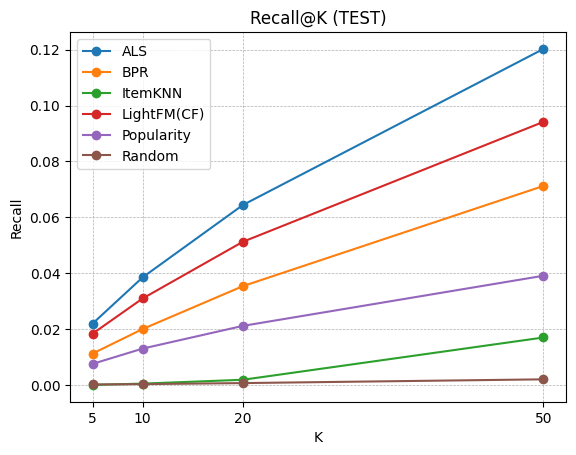

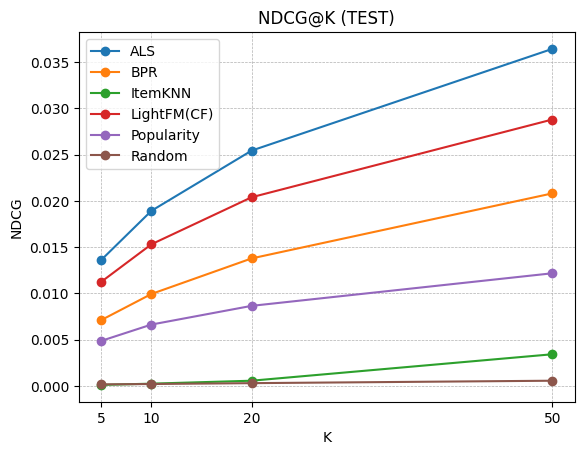

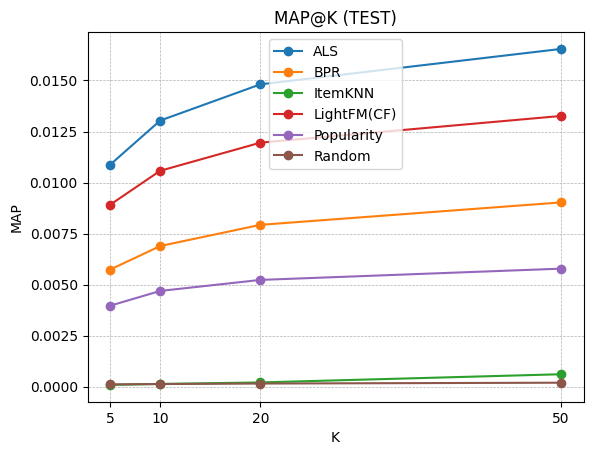

In [ ]:
import matplotlib.pyplot as plt

def plot_metric_vs_k(res, metric):
    pivot = res.pivot_table(index="K", columns="model", values=metric, aggfunc="first").sort_index()

    plt.figure()
    for model in pivot.columns:
        plt.plot(pivot.index.values, pivot[model].values, marker="o", label=model)

    plt.xlabel("K")
    plt.ylabel(metric)
    plt.title(f"{metric}@K (TEST)")
    plt.xticks(pivot.index.values)
    plt.grid(True, which="both", axis="both", linestyle="--", linewidth=0.5)
    plt.legend()
    plt.show()

plot_metric_vs_k(res, "Recall")
plot_metric_vs_k(res, "NDCG")
plot_metric_vs_k(res, "MAP")
